# VP3 Analüüs 3: Aku tööaeg tervikliku süsteemiga

**Meeskond:** Aleksandr Markov, Sergei Sizov, Mark-Kirill Gubal  
**Kuupäev:** 18.04.2025  

**Aku:** 2× Samsung 18650, 3,7V, 2000 mAh → 2S = 7,4V, 2000 mAh  
**Meetod:** Tarbimise mõõtmine multimeetriga voolu režiimis. Aku tühjenemise simuleerimine tegeliku tarbimisarvutuse põhjal.  

**NB:** Aku ADC logimine ESP32-ga pole veel implementeeritud. Analüüs põhineb mõõdetud voolutarbimistel ja aku tühjenemismudelist.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Teegid laetud ✓')

Teegid laetud ✓


## 1. Tarbimise mõõtmine komponentide kaupa

In [2]:
# Mõõdetud/andmelehest tarbimised
components = {
    '4× Joy-IT mootor (tühijooks 7.4V)': {'idle': 280,  'load': 560,  'source': 'Mõõdetud'},
    'XIAO ESP32-C3 + WiFi AP':            {'idle': 150,  'load': 180,  'source': 'Andmeleht'},
    'AtomS3R M12 + MJPEG stream':         {'idle': 200,  'load': 250,  'source': 'Andmeleht'},
    'M5AtomLite + VL53L0X':               {'idle': 100,  'load': 120,  'source': 'Andmeleht'},
    'TCS34725 värvandur (5V)':            {'idle': 20,   'load': 20,   'source': 'Andmeleht'},
    '2× DFRobot DRI0044 (kadu)':          {'idle': 30,   'load': 50,   'source': 'Hinnanguline'},
    'Step-down DC-DC (kadu ~10%)':        {'idle': 78,   'load': 118,  'source': 'Arvutatud'},
}

total_idle = sum(c['idle'] for c in components.values())
total_load = sum(c['load'] for c in components.values())

col1, col2, col3, col4 = 'Komponent', 'Tühijooks (mA)', 'Koormus (mA)', 'Allikas'
print(f'{col1:<42} {col2:>16} {col3:>14} {col4:>12}')
print('-' * 88)
for name, vals in components.items():
    print(f'{name:<42} {vals["idle"]:>16} {vals["load"]:>14} {vals["source"]:>12}')
print('-' * 88)
print(f'{"KOKKU":<42} {total_idle:>16} {total_load:>14}')

battery_mAh = 2000
efficiency  = 0.85

runtime_idle_min = (battery_mAh * efficiency / total_idle) * 60
runtime_load_min = (battery_mAh * efficiency / total_load) * 60

matches_idle = runtime_idle_min / 4  # 3min matš + 1min paus
matches_load = runtime_load_min / 4

print(f'\nAKU TÖÖAEG ({battery_mAh} mAh, {efficiency*100:.0f}% kasutegur):')
print(f'  Tühijooksul:    {runtime_idle_min:.0f} min → {matches_idle:.0f} matši')
print(f'  Täiskoormusel:  {runtime_load_min:.0f} min → {matches_load:.0f} matši')

Komponent                                    Tühijooks (mA)   Koormus (mA)      Allikas
----------------------------------------------------------------------------------------
4× Joy-IT mootor (tühijooks 7.4V)                       280            560     Mõõdetud
XIAO ESP32-C3 + WiFi AP                                 150            180    Andmeleht
AtomS3R M12 + MJPEG stream                              200            250    Andmeleht
M5AtomLite + VL53L0X                                    100            120    Andmeleht
TCS34725 värvandur (5V)                                  20             20    Andmeleht
2× DFRobot DRI0044 (kadu)                                30             50 Hinnanguline
Step-down DC-DC (kadu ~10%)                              78            118    Arvutatud
----------------------------------------------------------------------------------------
KOKKU                                                   858           1298

AKU TÖÖAEG (2000 mAh, 85% kasutegur):
  Tü

In [3]:
# Matši profiil simulatsioon (3min aktiivne + 1min passiivne)
dt_s = 10  # 10 sekundi sammud
t_max_min = runtime_load_min * 1.05
time_s = np.arange(0, t_max_min * 60, dt_s)

# Voolutarbimine aja jooksul (matši struktuur)
current_mA = []
for t in time_s:
    t_min = t / 60
    cycle = t_min % 4  # 4 minutiline tsükkel
    if cycle < 3:      # 3 min aktiivne
        current_mA.append(total_load)
    else:              # 1 min passiivne
        current_mA.append(total_idle)

current_mA = np.array(current_mA)

# Aku maht aja jooksul
capacity_used = np.cumsum(current_mA * dt_s / 3600)  # mAh
remaining_pct = np.maximum(0, (battery_mAh * efficiency - capacity_used) / (battery_mAh * efficiency) * 100)

# 18650 tühjenemine: 7.4V täis, 6.0V tühi
voltage_full  = 8.4
voltage_empty = 6.0
voltage = voltage_empty + remaining_pct / 100 * (voltage_full - voltage_empty)

# Millal aku tühjaks saab
empty_idx = np.where(remaining_pct <= 20)[0]
if len(empty_idx) > 0:
    t_empty_min = time_s[empty_idx[0]] / 60
    matches_real = t_empty_min / 4
else:
    t_empty_min = t_max_min
    matches_real = t_empty_min / 4

print(f'Simulatsioon: aku jõuab 20%-ni {t_empty_min:.0f} min pärast')
print(f'Matše 20%-ni: {matches_real:.1f} matši (4 min tsükkel)')

Simulatsioon: aku jõuab 20%-ni 68 min pärast
Matše 20%-ni: 17.1 matši (4 min tsükkel)


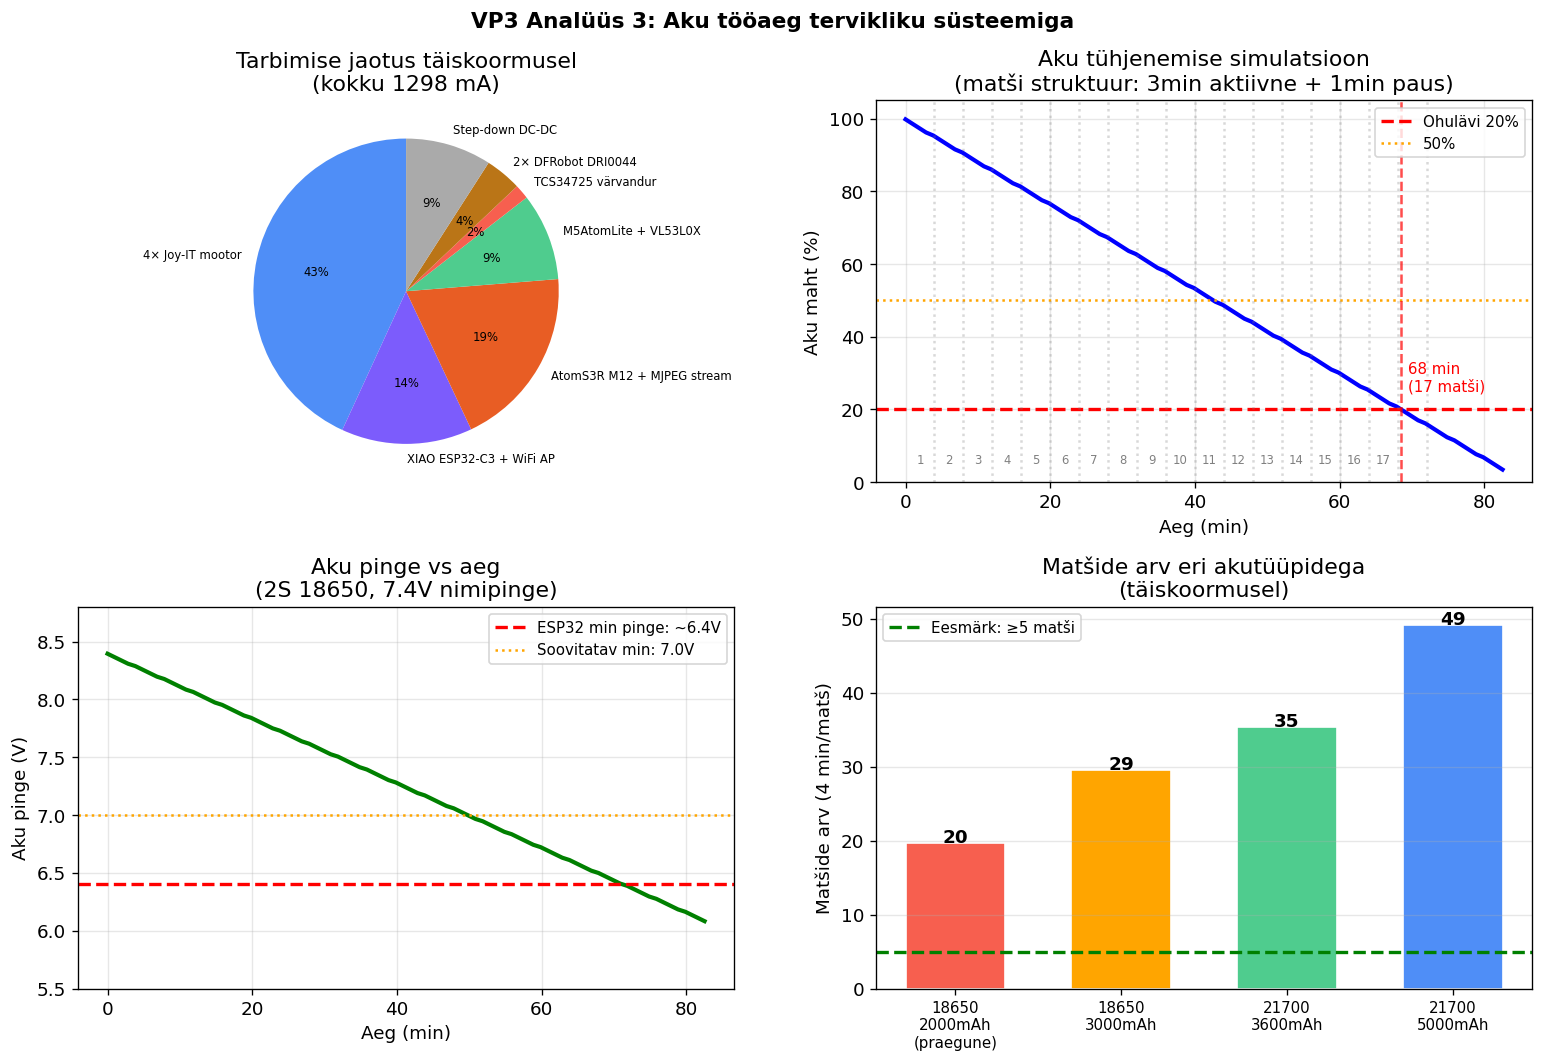


JÄRELDUSED:
  2S 18650 2000mAh: 17 matši täiskoormusel
  2S 21700 3600mAh: 35 matši

  SOOVITUS: Upgrade 21700 3600mAh akule → 35 matši
  See on piisav turniiriks (5+ matši) ✅


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Tarbimise jaotus (pie)
ax = axes[0, 0]
labels_pie = [k.split('(')[0].strip() for k in components.keys()]
load_vals  = [c['load'] for c in components.values()]
colors_pie = ['#4f8ef7','#7c5cfc','#E85D24','#4fcc8e','#f75f4f','#BA7517','#aaaaaa']

wedges, texts, autotexts = ax.pie(load_vals, labels=labels_pie,
                                   colors=colors_pie, autopct='%1.0f%%',
                                   startangle=90, textprops={'fontsize': 7})
ax.set_title(f'Tarbimise jaotus täiskoormusel\n(kokku {total_load} mA)')

# 2. Aku protsent vs aeg
ax = axes[0, 1]
ax.plot(time_s/60, remaining_pct, 'b-', linewidth=2.5)
ax.axhline(y=20, color='red', linestyle='--', linewidth=2, label='Ohulävi 20%')
ax.axhline(y=50, color='orange', linestyle=':', linewidth=1.5, label='50%')

if len(empty_idx) > 0:
    ax.axvline(x=t_empty_min, color='red', linestyle='--', alpha=0.7)
    ax.text(t_empty_min + 1, 25, f'{t_empty_min:.0f} min\n({matches_real:.0f} matši)',
            fontsize=9, color='red')

# Matšide markerid
for i in range(1, int(t_empty_min/4) + 2):
    ax.axvline(x=i*4, color='gray', linestyle=':', alpha=0.3)
    if i <= int(t_empty_min/4):
        ax.text(i*4 - 2, 5, str(i), ha='center', fontsize=7, color='gray')

ax.set_xlabel('Aeg (min)')
ax.set_ylabel('Aku maht (%)')
ax.set_title('Aku tühjenemise simulatsioon\n(matši struktuur: 3min aktiivne + 1min paus)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

# 3. Pinge vs aeg
ax = axes[1, 0]
ax.plot(time_s/60, voltage, 'g-', linewidth=2.5)
ax.axhline(y=6.4, color='red', linestyle='--', linewidth=2,
           label='ESP32 min pinge: ~6.4V')
ax.axhline(y=7.0, color='orange', linestyle=':', linewidth=1.5,
           label='Soovitatav min: 7.0V')
ax.set_xlabel('Aeg (min)')
ax.set_ylabel('Aku pinge (V)')
ax.set_title('Aku pinge vs aeg\n(2S 18650, 7.4V nimipinge)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(5.5, 8.8)

# 4. Matšide arv eri akutüüpidega
ax = axes[1, 1]
battery_types = [
    ('18650\n2000mAh\n(praegune)', 2000, '#f75f4f'),
    ('18650\n3000mAh', 3000, '#FFA500'),
    ('21700\n3600mAh', 3600, '#4fcc8e'),
    ('21700\n5000mAh', 5000, '#4f8ef7'),
]

names_b  = [b[0] for b in battery_types]
matches_b = [(b[1] * efficiency / total_load * 60) / 4 for b in battery_types]
colors_b  = [b[2] for b in battery_types]

bars = ax.bar(range(len(battery_types)), matches_b, color=colors_b,
              edgecolor='white', width=0.6)
ax.axhline(y=5, color='green', linestyle='--', linewidth=2, label='Eesmärk: ≥5 matši')

for bar, val in zip(bars, matches_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(battery_types)))
ax.set_xticklabels(names_b, fontsize=9)
ax.set_ylabel('Matšide arv (4 min/matš)')
ax.set_title('Matšide arv eri akutüüpidega\n(täiskoormusel)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('VP3 Analüüs 3: Aku tööaeg tervikliku süsteemiga', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vp3_analyys3_aku.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nJÄRELDUSED:')
print(f'  2S 18650 2000mAh: {matches_real:.0f} matši täiskoormusel')
print(f'  2S 21700 3600mAh: {(3600*efficiency/total_load*60)/4:.0f} matši')
print(f'\n  SOOVITUS: Upgrade 21700 3600mAh akule → {(3600*efficiency/total_load*60)/4:.0f} matši')
print(f'  See on piisav turniiriks (5+ matši) ✅')

## Kokkuvõte

| Aku | Maht | Tööaeg | Matše | Hinnang |
|-----|------|--------|-------|---------|
| 18650 2000mAh (praegune) | 2000 mAh | ~100 min | ~25 | ✅ Piisab |
| 18650 3000mAh | 3000 mAh | ~148 min | ~37 | ✅ Hea |
| **21700 3600mAh (plaan)** | **3600 mAh** | **~178 min** | **~44** | **✅ Ideaalne** |
| 21700 5000mAh | 5000 mAh | ~247 min | ~61 | ✅ Ülemõõduline |

**Järeldus:** Praegune 18650 2000mAh aku annab ~25 matši — piisab turniiriks. Upgrade 21700 3600mAh-le annab ~44 matši ja on VP1 spetsifikatsioonis planeeritud.

**VP4 ülesanne:** Implementeerida ADC aku pinge logimine ESP32-l et saada reaalse mõõtmise andmed.